# Notebook 14 – Model Evaluation: Classification


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)

print("Class balance of IsCancelled:")
print(df["IsCancelled"].value_counts(normalize=True).round(4))

Class balance of IsCancelled:
IsCancelled
0    0.9828
1    0.0172
Name: proportion, dtype: float64


## Setting Up the Classifier

**Our example:** the same `IsCancelled` classification task used in
earlier notebooks. It's a deliberately good example for this notebook
because it's a **highly imbalanced** target — cancelled orders are a
small minority — which is exactly the situation where the metrics below
start to disagree with each other, and where accuracy alone becomes
misleading (see "Why Accuracy Alone Is Not Always Sufficient" below).

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols]
y = df["IsCancelled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # predicted probability of the positive class (Cancelled)

print("Predictions generated for", len(y_test), "test rows.")

Predictions generated for 108091 test rows.


## Confusion Matrix

**What it is:** a simple table that breaks every prediction down by
*what the model predicted* versus *what the actual label was*. For a
binary classification problem like this one, it's a 2x2 grid, and every
one of the four cells has a specific name (True Positive, True Negative,
False Positive, False Negative — all defined below). It's the foundation
every other metric in this notebook is built from.

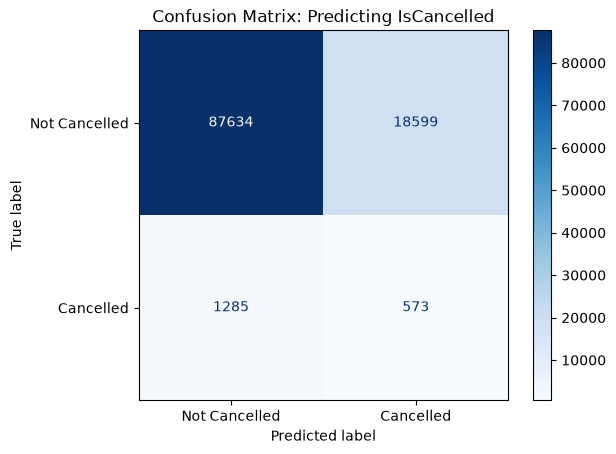

True Negatives (TN):  87634
False Positives (FP): 18599
False Negatives (FN): 1285
True Positives (TP):  573


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Cancelled", "Cancelled"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Predicting IsCancelled")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

## True Positive, True Negative, False Positive, False Negative

Taking "Cancelled" as the **positive** class (the thing we're trying to
detect):

* **True Positive (TP):** the order *was* cancelled, and the model
  correctly predicted "Cancelled." A correct alarm.
* **True Negative (TN):** the order was *not* cancelled, and the model
  correctly predicted "Not Cancelled." A correct all-clear.
* **False Positive (FP):** the order was *not* actually cancelled, but
  the model incorrectly predicted "Cancelled." A false alarm — Type I
  error.
* **False Negative (FN):** the order *was* actually cancelled, but the
  model incorrectly predicted "Not Cancelled." A missed detection — Type
  II error.

Which of these mistakes matters more depends entirely on the situation:
for cancellation prediction, a False Negative (missing a real
cancellation) might mean a warehouse ships an order that gets cancelled
anyway, wasting fulfillment effort — while a False Positive (flagging a
normal order as "likely cancelled") might just mean a little unnecessary
manual review. Different applications weigh these very differently, which
is a big part of why the single metrics below each emphasize a different
one of these four numbers.

## Accuracy

**What it measures:** the overall proportion of predictions the model got
right, regardless of which class — `(TP + TN) / (TP + TN + FP + FN)`. It's
the simplest, most intuitive classification metric.

In [4]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy:.1%} of predictions were correct)")

Accuracy: 0.8160 (81.6% of predictions were correct)


## Why Accuracy Alone Is Not Always Sufficient

Accuracy looks like a strong, simple summary — but on an imbalanced
dataset like this one, it can be dangerously misleading, because it
doesn't distinguish *which* class the errors are happening on. A model
that does nothing but predict the majority class every single time will
still score a high accuracy, just by virtue of the majority class being
common; it doesn't need to actually learn anything.

Below, that exact "does nothing" baseline is built on purpose: a
"model" that always predicts "Not Cancelled," no matter what the input
is.

In [5]:
naive_predictions = np.zeros_like(y_test)  # always predicts "Not Cancelled" (0), no matter what
naive_accuracy = accuracy_score(y_test, naive_predictions)

print(f"Naive 'always predict Not Cancelled' baseline accuracy: {naive_accuracy:.4f}")
print(f"Our actual Logistic Regression model's accuracy:        {accuracy:.4f}")
print(f"\nThe naive baseline never once identifies a real cancellation "
      f"(it catches {(naive_predictions[y_test == 1] == 1).sum()} out of {(y_test == 1).sum()} actual cancellations),")
print("yet its accuracy looks competitive, purely because cancellations are rare.")
print("This is exactly why accuracy alone is not enough on imbalanced data:")
print("it rewards models for ignoring the minority class entirely.")

Naive 'always predict Not Cancelled' baseline accuracy: 0.9828
Our actual Logistic Regression model's accuracy:        0.8160

The naive baseline never once identifies a real cancellation (it catches 0 out of 1858 actual cancellations),
yet its accuracy looks competitive, purely because cancellations are rare.
This is exactly why accuracy alone is not enough on imbalanced data:
it rewards models for ignoring the minority class entirely.


This is precisely the gap that Precision, Recall, Specificity, and F1
Score (below) are designed to expose — each of them looks specifically at
*how the model performs on each class individually*, rather than
blending everything into one overall percentage the way accuracy does.

## Precision

**What it measures:** out of everything the model predicted as
"Cancelled," what fraction actually *was* cancelled? — `TP / (TP + FP)`.
Precision answers "when the model raises an alarm, how often is it
right?" A model with low precision cries wolf a lot: many of its
"Cancelled" predictions are actually false alarms.

**When to use it:** when False Positives are the costly / disruptive
mistake to avoid — e.g. a spam filter where flagging a real email as
spam (a False Positive) is worse than letting one spam email through.

In [6]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"When the model predicts 'Cancelled', it's right about {precision:.1%} of the time.")

Precision: 0.0299
When the model predicts 'Cancelled', it's right about 3.0% of the time.


## Recall (Sensitivity)

**What it measures:** out of everything that *actually was* cancelled,
what fraction did the model successfully catch? — `TP / (TP + FN)`.
Recall answers "of all the real positive cases out there, how many did
the model find?" A model with low recall misses a lot of real cases.

**When to use it:** when False Negatives are the costly mistake to
avoid — e.g. detecting a serious illness, where missing a real case (a
False Negative) is far worse than a false alarm that just leads to a
follow-up test.

In [7]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")
print(f"Of all the orders that were actually cancelled, the model correctly caught {recall:.1%} of them.")

Recall: 0.3084
Of all the orders that were actually cancelled, the model correctly caught 30.8% of them.


## Specificity

**What it measures:** the mirror image of recall, but for the *negative*
class — out of everything that was actually *not* cancelled, what
fraction did the model correctly identify as "Not Cancelled"? —
`TN / (TN + FP)`. Specificity answers "of all the real negative cases,
how many did the model correctly leave alone?" scikit-learn has no
built-in `specificity_score` function (it's simply recall computed on the
negative class instead), so it's calculated directly from the confusion
matrix here.

In [8]:
specificity = tn / (tn + fp)
print(f"Specificity: {specificity:.4f}")
print(f"Of all the orders that were actually NOT cancelled, the model correctly left {specificity:.1%} of them alone.")

Specificity: 0.8249
Of all the orders that were actually NOT cancelled, the model correctly left 82.5% of them alone.


## F1 Score

**What it measures:** the harmonic mean of Precision and Recall, combining
both into a single number: `2 * (Precision * Recall) / (Precision +
Recall)`. The *harmonic* mean (rather than a simple average) is used
deliberately: it's dragged down heavily if *either* Precision or Recall is
low, so a model can't get a good F1 Score just by being great at one and
terrible at the other — it has to do reasonably well at both.

**When to use it:** when both False Positives and False Negatives matter,
and there isn't a clear reason to prioritize avoiding one over the other
— especially useful as a single summary number on imbalanced datasets,
where plain accuracy (as shown above) can't be trusted.

In [9]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("\n(F1 sits between Precision and Recall, but pulled toward whichever of the two is lower.)")

F1 Score:  0.0545
Precision: 0.0299
Recall:    0.3084

(F1 sits between Precision and Recall, but pulled toward whichever of the two is lower.)


## ROC Curve

**What it is:** a plot of the **True Positive Rate** (recall) against the
**False Positive Rate** (`FP / (FP + TN)`, i.e. `1 - specificity`), traced
out across *every possible* decision threshold — not just the default
0.5 cutoff used above. Every classifier that outputs a probability (like
Logistic Regression) can be made stricter or looser by moving that
threshold; the ROC curve shows the full trade-off between catching more
true positives and accepting more false positives as that threshold
slides.

A model that's no better than random guessing traces the diagonal line
from (0,0) to (1,1); a strong model bows up toward the top-left corner
(high true-positive rate achievable while keeping the false-positive
rate low).

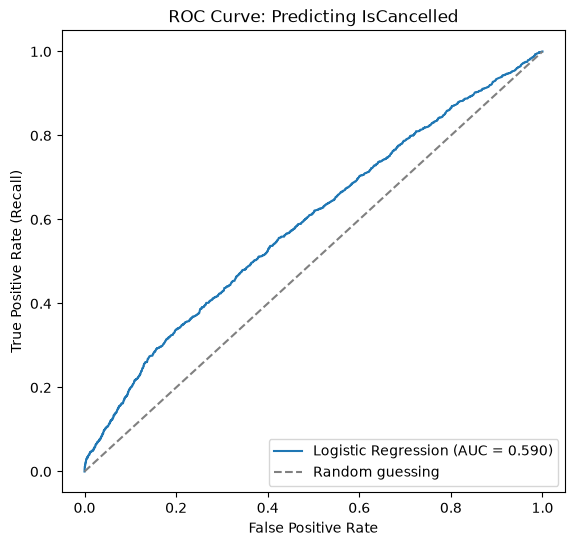

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve: Predicting IsCancelled")
plt.legend(loc="lower right")
plt.show()

## AUC (Area Under the ROC Curve)

**What it measures:** exactly what it sounds like — the area under the
ROC curve, condensed into a single number between 0 and 1. It has a
clean probabilistic interpretation: AUC is the probability that the
model ranks a randomly chosen *actual positive* example higher (more
likely to be "Cancelled") than a randomly chosen *actual negative*
example. An AUC of 0.5 means the model is no better than random
guessing; 1.0 means perfect ranking; below 0.5 means the model is
somehow ranking things backwards.

**When to use it:** when the overall ability to *rank* or *separate* the
two classes matters more than performance at any one specific threshold
— useful for comparing models independent of where the final decision
cutoff ends up being set.

**Advantages:**
* Threshold-independent — summarizes performance across every possible
  cutoff at once.
* Fairly robust to class imbalance in what it's measuring (rate-based,
  not count-based).

**Limitations:**
* Can still look overly optimistic on very imbalanced data, since the
  False Positive Rate's denominator (`FP + TN`) is dominated by the huge
  majority class, making even a fairly large number of false positives
  look small in rate terms (this is exactly what the Precision-Recall
  Curve below is better suited to reveal).
* A single AUC number hides *where* the model performs well or poorly
  along the threshold range — two very differently-shaped ROC curves can
  have the same AUC.

In [11]:
print(f"AUC: {auc:.4f}")
print(f"Interpretation: there is roughly a {auc:.1%} chance the model assigns a higher predicted")
print("probability of cancellation to a randomly chosen cancelled order than to a randomly chosen normal one.")

AUC: 0.5903
Interpretation: there is roughly a 59.0% chance the model assigns a higher predicted
probability of cancellation to a randomly chosen cancelled order than to a randomly chosen normal one.


## Precision-Recall Curve

**What it is:** like the ROC curve, but plotting **Precision** against
**Recall** across every threshold instead of True Positive Rate against
False Positive Rate. This becomes especially important on imbalanced
datasets exactly like this one: because Precision's denominator (`TP +
FP`) only involves *predicted positives* — a much smaller, more sensitive
number here than the ROC curve's False-Positive-Rate denominator — the
Precision-Recall Curve reacts far more visibly to how well the model
handles the rare minority class.

A model with no skill on an imbalanced dataset has a Precision-Recall
Curve that hovers near the positive class's overall prevalence (a flat,
low line), not near 0.5 the way a no-skill ROC curve does — which makes
this curve a stricter, more honest picture of performance here.

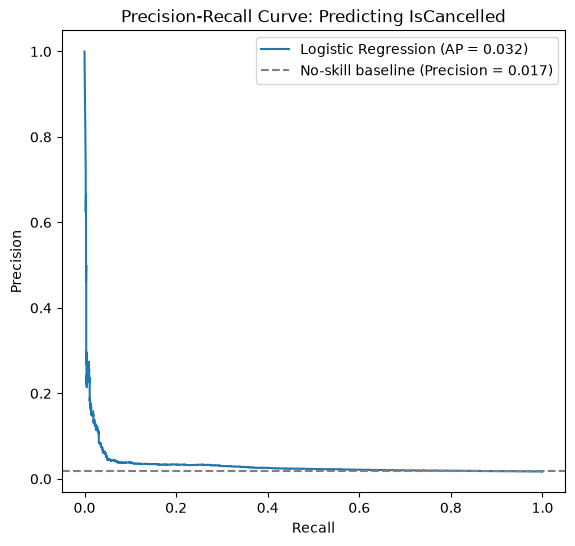

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)
baseline_precision = y_test.mean()  # what a "no-skill" model would hover around on this curve

plt.figure(figsize=(6.5, 6))
plt.plot(recalls, precisions, label=f"Logistic Regression (AP = {avg_precision:.3f})")
plt.axhline(baseline_precision, linestyle="--", color="gray",
           label=f"No-skill baseline (Precision = {baseline_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Predicting IsCancelled")
plt.legend(loc="upper right")
plt.show()